## References HRV Method
 [1] Chiu P-W, Bloebaum, CL (2008a) 
     Hyper-radial visualization (HRV) with weighted preferences for multi-objective decision making. 
     12th AIAA/ISSMO Multidisciplinary Analysis and Optimization Conference.
     Victoria, British Columbia, Canada, AIAA, AIAA-2008-5986

 [2] Chiu P-W, Bloebaum, CL (2008b) 
     Hyper-radial visualization (HRV) for Decision-making in MOO. 
     46th AIAA Aerospace Sciences Meeting and Exhibit
     7 - 10 January 2008, Reno, Nevada

In [145]:
import numpy as np
import pandas as pd
import itertools
import matplotlib.pyplot as plt
from collections import defaultdict

In [146]:
def HRV_method_2(XX, type="full", IDx=None, verbose=True):
    """
    Python translation of MATLAB function HRV_method_2
    Created by: 
    Mario Castro Gama ir, MSc, PhD
    Last Update: 2016.09.22 
    Last Update: 2022.05.11

    Parameters
    ----------
    XX : ndarray (nsol, nobj)
        Objective matrix
    type : str
        Renormalization type ('full' or 'max')
    IDx : array-like or None
        Solution indices

    Returns
    -------
    best_sol : ndarray
        Indices of best solutions (0-based)
    freq_sol : ndarray
        Frequency of each solution per partition size
    """

    XX = np.asarray(XX, dtype=float)
    nsol, nobj = XX.shape

    if IDx is None:
        IDx = np.arange(1, nsol + 1)   # MATLAB-style labels

    if type is None or type == "":
        type = "full"

    # ---- Normalize objectives ----
    XX2 = rescale_objs(XX, type)

    norm_type = 2  # Euclidean

    # ---- Generate random objective splittings ----
    ntrials = (2 ** nobj) ** 2
    combos = np.random.randint(0, 2, size=(ntrials, nobj))

    combos = np.unique(combos, axis=0)

    # First objective must be in group 0
    combos = combos[combos[:, 0] == 0]

    if np.all(combos[0] == 0):
        combos = combos[1:]

    # Ensure sum <= nobj / 2
    for i in range(len(combos)):
        if combos[i].sum() >= nobj / 2:
            combos[i] = 1 - combos[i]

    # Sort by group size
    sums = combos.sum(axis=1)
    order = np.argsort(sums)
    combos = combos[order]
    sums = sums[order]

    combos = np.hstack([1 - combos, sums[:, None]])
    order = np.lexsort(combos[:, :-1].T[::-1] + [combos[:, -1]])
    combos = combos[order]

    n_s1s2 = combos[:, -1].astype(int)
    combos = combos[:, :nobj]

    ncombos = combos.shape[0]

    # ---- Initialize frequency matrix ----
    freq_sol = np.zeros((nsol, int(np.max(n_s1s2))), dtype=int)

    # ---- Plot setup ----
    FlagPlot = ncombos <= 25

    if FlagPlot:
        ncols = round(ncombos ** 0.5) + 1
        nrows = int(np.ceil(ncombos / ncols))
        sel_fontsize = 20 - ncols
        text_size = 18 - ncols

        fig = plt.figure(figsize=(12, 6), facecolor="white", constrained_layout=True)#, sharex = True, sharey= True)

    # ---- Main HRV loop ----
    for icombo in range(ncombos):

        sel_1 = np.where(combos[icombo] == 0)[0]
        sel_2 = np.where(combos[icombo] == 1)[0]

        s1 = len(sel_1)
        s2 = len(sel_2)

        euc1 = norm_forall(XX2[:, sel_1], norm_type) / np.sqrt(s1)
        euc2 = norm_forall(XX2[:, sel_2], norm_type) / np.sqrt(s2)

        euc3 = norm_forall(np.column_stack([euc1, euc2]), norm_type)

        idx_min = np.argmin(euc3)
        euc_min = euc3[idx_min]

        freq_sol[idx_min, n_s1s2[icombo] - 1] += 1

        HRstr = (
            f"HR_{{{sel_2 + 1}}} vs HR_{{{sel_1 + 1}}} : S_{{{IDx[idx_min]}}}"
        )
        if verbose == True:
            print(HRstr)

        if FlagPlot:
            ax = fig.add_subplot(nrows, ncols, icombo + 1)
            ax.plot(euc1, euc2, ".", markersize=4)
            ax.plot(
                euc1[idx_min],
                euc2[idx_min],
                "ro",
                markerfacecolor="y",
                markersize=8,
                linewidth=1,
                alpha = 0.3,
            )

            ax.text(
                #0.075, 0.825, HRstr,
                0.675, 0.825, '$S_{'+str(IDx[idx_min])+'}$', 
                transform = ax.transAxes,
                fontsize  = text_size - 4,
                #fontweight="bold",
                bbox      = dict(facecolor="white", edgecolor="black"),
                verticalalignment = "bottom"
            )
            ax.set_ylabel('$HR_{'+str(sel_2 + 1)+'}$')
            ax.set_xlabel('$HR_{'+str(sel_1 + 1)+'}$')
            
            ax.set_xlim(-0.05, 1.05)
            ax.set_ylim(-0.05, 1.05)
            ax.set_xticks([ 0.0, 0.5, 1.0])
            ax.set_yticks([ 0.0, 0.5, 1.0])
            #ax.set_xscale('log')
            #ax.set_yscale('log')
            #ax.set_aspect('equal','box')
            #ax.grid(True)
            ax.grid(which='both')

    # ---- Extract best solutions ----
    best_sol = np.where(freq_sol.sum(axis=1) > 0)[0]
    freq_sol = freq_sol[best_sol, :]

    return best_sol, freq_sol

In [147]:
def rescale_objs(X, mode="full"):
    X = np.asarray(X, dtype=float)

    if mode == "full":
        return (X - X.min(axis=0)) / (X.max(axis=0) - X.min(axis=0))
    elif mode == "max":
        return X / X.max(axis=0)
    else:
        raise ValueError("Unknown scaling mode")

In [148]:
def norm_forall(X, p=2):
    return np.linalg.norm(X, ord=p, axis=1)

In [149]:
def view_HRV_freq(best_sol,freq_sol,dx=6,ys='log'):
    nsols = len(best_sol)
    n_exp = np.ceil(np.log10(freq_sol.sum(axis=1).max()))
    plt.figure(figsize=(10, 5))
    x = np.arange(0,nsols)
    plt.bar(x,freq_sol.sum(axis=1),width=0.5)
    plt.xticks(x[0::dx],labels=best_sol[0::dx],rotation=90)
    plt.xlim(-1,nsols)
    plt.ylim(0.2,1.05*10**n_exp)
    if ys == 'linear':
        plt.yscale('linear')
    elif ys == 'log':
        plt.yscale('log')
    plt.grid(True,which='both')
    plt.title('Frequency of each HRV solution')
    plt.ylabel('Frequency')
    plt.xlabel('id solution')
    plt.show()
    return 'A total of '+str(nsols)+' solutions identified'

## 1. MOO WDN Design (4 Objectives)

In [150]:
# load the CSV file with the MOO results
#df = pd.read_csv('Modena_WDN_design_Integer.csv')
df_wdn = pd.read_csv('MOO_MOD_4OBJ_Integer/Modena_WDN_design_Integer_50mm_interval.csv')

# Leveringszekerheid is maximization
df_wdn['LevZek'] = -df_wdn['LevZek']

# rename columns to include units
df_wdn.rename(columns={'TC':'Total Cost [Meur]',
                   'Pmin_diff':'Presidual [m]',
                   'Pmax':'Pmax [m]',
                   'LevZek':'Levering Zekerheid [0-1]'},
          inplace=True)

# Include a column for the generation number (for animation)
df_wdn.insert(0,'gen', np.floor(df_wdn.index/100))

# name of columns of diameters
diameter_indexes = df_wdn.keys()[5:]

# show the dataframe
df_wdn = df_wdn[df_wdn['Presidual [m]'] < 1000]
df_wdn

,gen,Total Cost [Meur],Presidual [m],Pmax [m],Levering Zekerheid [0-1],D1,D2,D3,D4,D5,...,D308,D309,D310,D311,D312,D313,D314,D315,D316,D317
0,0.0,5.335408,434.920227,41.462429,0.947761,100,500,400,200,250,...,500,150,550,450,50,150,250,400,650,400
1,0.0,5.790327,512.247925,39.219818,0.854478,500,300,400,250,550,...,450,450,350,600,200,450,350,500,650,350
2,0.0,5.066292,358.488464,40.684586,0.891791,550,450,600,400,250,...,600,350,200,600,650,450,250,400,150,50
3,0.0,5.334700,369.765137,39.569866,0.283582,300,550,400,150,650,...,350,500,100,450,250,300,600,300,300,500
4,0.0,5.047110,485.584778,38.266155,0.317164,150,400,500,450,300,...,150,100,450,600,250,50,100,400,100,350
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
13760,137.0,2.578654,158.593658,34.830566,0.559701,300,350,350,300,100,...,150,400,250,400,350,350,100,300,100,50
13761,137.0,2.550281,45.218601,34.438465,0.757463,350,550,100,100,150,...,300,250,150,250,250,350,150,350,100,50
13762,137.0,3.188643,1.838527,30.336807,0.966418,350,300,300,350,50,...,300,400,250,250,250,350,200,350,50,50
13763,137.0,3.039205,51.117664,29.076321,0.742537,350,300,300,300,100,...,50,400,250,150,250,350,200,300,50,50


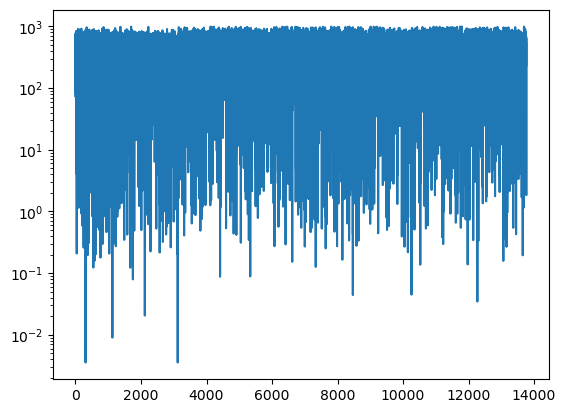

In [151]:
(df_wdn['Presidual [m]']).plot().set_yscale('log')

In [152]:
OF_wdn = df_wdn[['Total Cost [Meur]','Presidual [m]','Pmax [m]','Levering Zekerheid [0-1]']].to_numpy()
OF_wdn[3679:,:].shape

(10000, 4)

array([[<Axes: xlabel='Total Cost [Meur]', ylabel='Total Cost [Meur]'>,
        <Axes: xlabel='Presidual [m]', ylabel='Total Cost [Meur]'>,
        <Axes: xlabel='Pmax [m]', ylabel='Total Cost [Meur]'>,
        <Axes: xlabel='Levering Zekerheid [0-1]', ylabel='Total Cost [Meur]'>],
       [<Axes: xlabel='Total Cost [Meur]', ylabel='Presidual [m]'>,
        <Axes: xlabel='Presidual [m]', ylabel='Presidual [m]'>,
        <Axes: xlabel='Pmax [m]', ylabel='Presidual [m]'>,
        <Axes: xlabel='Levering Zekerheid [0-1]', ylabel='Presidual [m]'>],
       [<Axes: xlabel='Total Cost [Meur]', ylabel='Pmax [m]'>,
        <Axes: xlabel='Presidual [m]', ylabel='Pmax [m]'>,
        <Axes: xlabel='Pmax [m]', ylabel='Pmax [m]'>,
        <Axes: xlabel='Levering Zekerheid [0-1]', ylabel='Pmax [m]'>],
       [<Axes: xlabel='Total Cost [Meur]', ylabel='Levering Zekerheid [0-1]'>,
        <Axes: xlabel='Presidual [m]', ylabel='Levering Zekerheid [0-1]'>,
        <Axes: xlabel='Pmax [m]', ylabel='Leverin

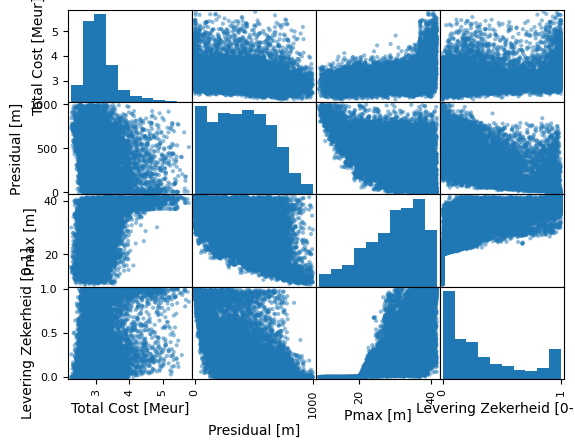

In [153]:
pd.plotting.scatter_matrix(df_wdn[['Total Cost [Meur]','Presidual [m]','Pmax [m]','Levering Zekerheid [0-1]']])

HR_{[2 3 4]} vs HR_{[1]} : S_{8856}
HR_{[1 3 4]} vs HR_{[2]} : S_{9853}
HR_{[1 2 4]} vs HR_{[3]} : S_{8856}
HR_{[1 2 3]} vs HR_{[4]} : S_{8856}
HR_{[3 4]} vs HR_{[1 2]} : S_{8856}
HR_{[2 4]} vs HR_{[1 3]} : S_{8856}
HR_{[2 3]} vs HR_{[1 4]} : S_{8856}


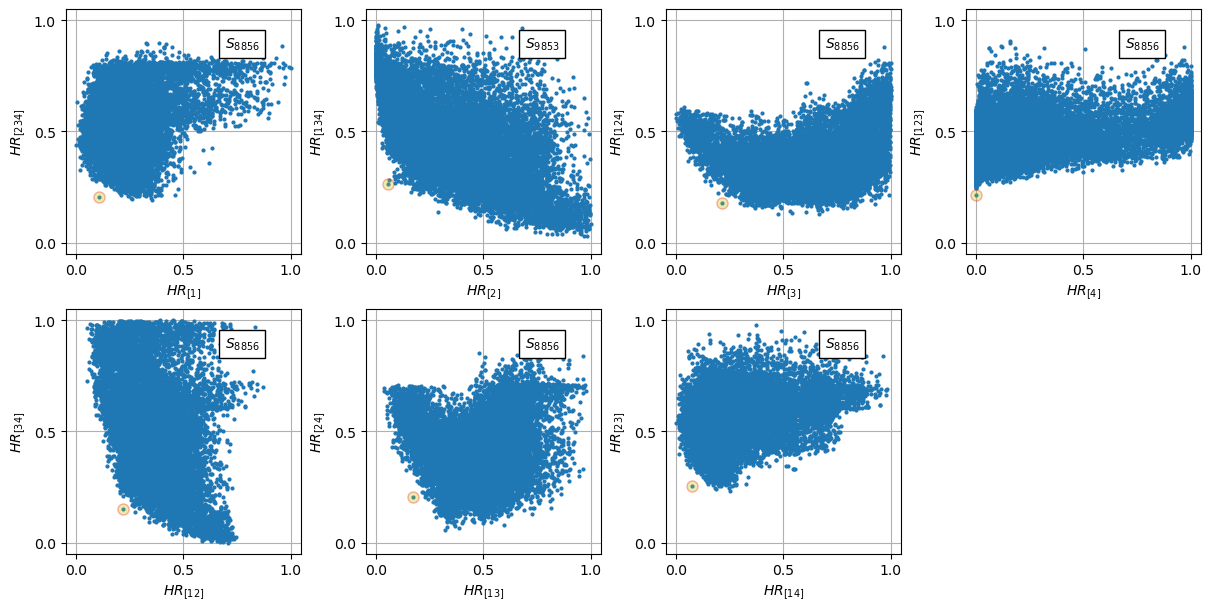

In [154]:
best_sol_wdn, freq_sol_wdn = HRV_method_2(OF_wdn, type="full", IDx=None, verbose=True)

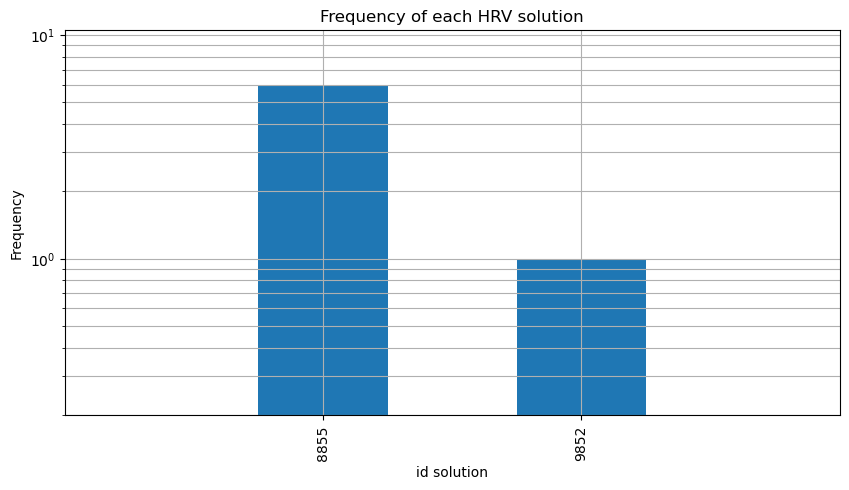

'A total of 2 solutions identified'

In [155]:
view_HRV_freq(best_sol_wdn,freq_sol_wdn,dx=1)

## 2. WATER (Ray, Tai & Seow) problem : 5 Objectives)

In [156]:
dfw = pd.read_csv('WATER/WATER_NSGA2_500k.txt')

In [157]:
OFw = dfw[['F_1','F_2','F_3','F_4','F_5']].to_numpy()
OFw.shape

(499133, 5)

HR_{[2 3 4 5]} vs HR_{[1]} : S_{387247}
HR_{[1 3 4 5]} vs HR_{[2]} : S_{98938}
HR_{[1 2 4 5]} vs HR_{[3]} : S_{146750}
HR_{[1 2 3 5]} vs HR_{[4]} : S_{363516}
HR_{[1 2 3 4]} vs HR_{[5]} : S_{296912}
HR_{[3 4 5]} vs HR_{[1 2]} : S_{131180}
HR_{[2 4 5]} vs HR_{[1 3]} : S_{120618}
HR_{[2 3 5]} vs HR_{[1 4]} : S_{170403}
HR_{[2 3 4]} vs HR_{[1 5]} : S_{161977}
HR_{[1 4 5]} vs HR_{[2 3]} : S_{496974}
HR_{[1 3 5]} vs HR_{[2 4]} : S_{278785}
HR_{[1 3 4]} vs HR_{[2 5]} : S_{157630}
HR_{[1 2 5]} vs HR_{[3 4]} : S_{481327}
HR_{[1 2 4]} vs HR_{[3 5]} : S_{185520}
HR_{[1 2 3]} vs HR_{[4 5]} : S_{134282}


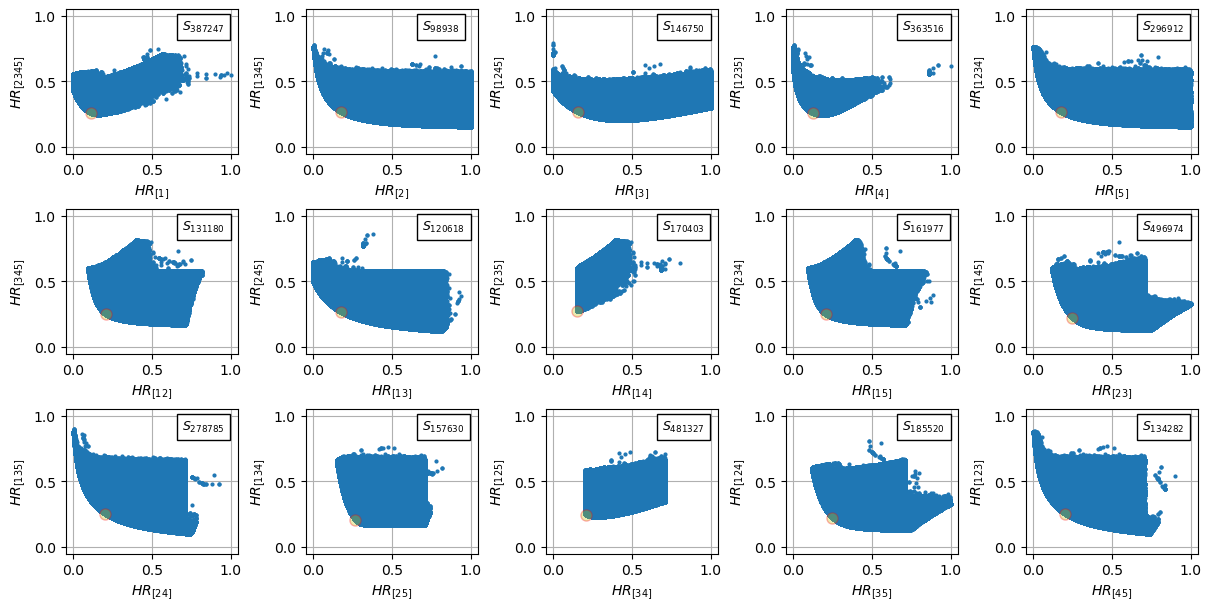

In [158]:
best_sol_w, freq_sol_w = HRV_method_2(OFw, type="full", IDx=None)

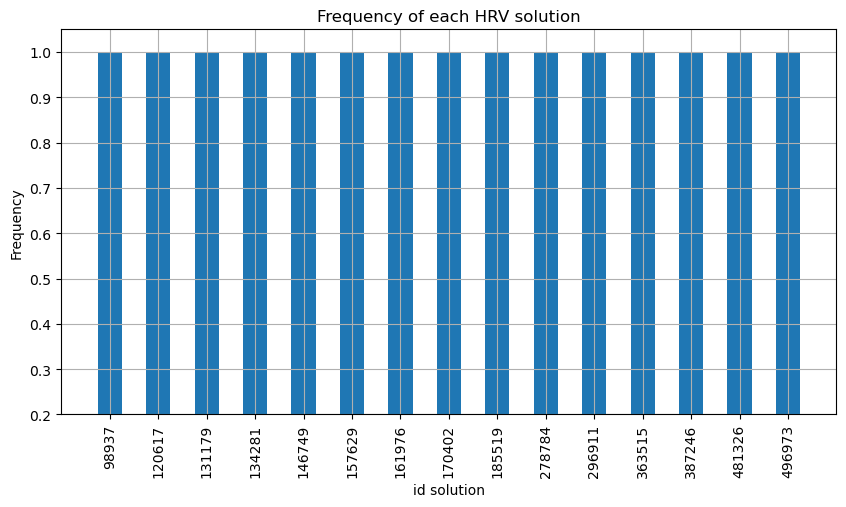

'A total of 15 solutions identified'

In [159]:
view_HRV_freq(best_sol_w,freq_sol_w,dx=1,ys='linear')

In [160]:
best_sol_w

array([ 98937, 120617, 131179, 134281, 146749, 157629, 161976, 170402,
       185519, 278784, 296911, 363515, 387246, 481326, 496973])

In [161]:
freq_sol_w.T

array([[1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 1, 1, 0, 0],
       [0, 1, 1, 1, 0, 1, 1, 1, 1, 1, 0, 0, 0, 1, 1]])

## 3. Veldhuizen problem (8 Objectives)

In [162]:
# Now test the HRV with the results from the Veldhuizen benchmark problem

In [163]:
df_vhz = pd.read_csv('veldhuizen/Veldhuizen_500k.txt')

# Include a column for the generation number (for animation)
df_vhz.insert(0,'gen', np.floor(df_vhz.index/500))

# show the dataframe
df_vhz

,F_1,F_2,F_3,F_4,F_5,F_6,F_7,F_8,G_1,G_2,G_3,X_1,X_2
0,3.185007,-10.021180,16.301679,33.964750,-15.982831,104.104053,2.801634,5.197258,-0.017998,-1.094573,-5.509137,0.094573,3.603710
1,3.437599,-9.408725,17.372953,33.640398,-15.473515,105.198878,2.832317,5.514073,-0.627991,-0.881528,-5.964370,-0.118472,3.845898
2,4.126031,-12.072401,15.038190,32.824793,-15.745511,96.542821,3.559415,3.482400,-1.627314,-1.087111,-3.937131,0.087111,2.024242
3,7.479762,-12.609464,17.015970,29.605538,-16.278576,84.244930,7.308378,-0.450372,-9.461391,-0.001176,-1.532729,-0.998824,-1.466095
4,6.766669,-11.749626,15.879997,30.850864,-12.914512,95.285818,4.532210,3.253707,-6.024072,-0.043394,-4.758957,-0.956606,1.802352
...,...,...,...,...,...,...,...,...,...,...,...,...,...
499297,5.201759,-11.007670,16.217948,31.970123,-14.025966,99.042704,3.690486,4.149440,-3.512643,-0.462413,-5.175292,-0.537587,2.637705
499298,3.306984,-9.410483,17.257607,33.784167,-15.643218,105.371409,2.789758,5.531375,-0.389111,-0.934909,-5.936347,-0.065091,3.871255
499299,3.123292,-9.343293,17.200919,33.990968,-15.862734,105.779966,2.723912,5.599638,-0.060707,-0.999957,-5.939510,-0.000043,3.939467
499300,4.358967,-12.919467,16.562013,32.225603,-16.427160,90.699490,4.302392,2.090552,-2.457892,-1.236542,-2.359399,0.236542,0.595941


In [171]:
df_vhz.shape[0]-10000

489302

In [172]:
OFnames_vhz = ['F_1','F_2','F_3','F_4','F_5','F_6','F_7','F_8']
OF_vhz = df_vhz[OFnames_vhz].to_numpy()
OF_vhz[489302:,:].shape

(10000, 8)

In [173]:
best_sol_vhz, freq_sol_vhz = HRV_method_2(OF_vhz[489302:,:], type="full", IDx=None)

HR_{[2 3 4 5 6 7 8]} vs HR_{[1]} : S_{315}
HR_{[1 3 4 5 6 7 8]} vs HR_{[2]} : S_{1256}
HR_{[1 2 4 5 6 7 8]} vs HR_{[3]} : S_{4681}
HR_{[1 2 3 5 6 7 8]} vs HR_{[4]} : S_{9809}
HR_{[1 2 3 4 6 7 8]} vs HR_{[5]} : S_{3307}
HR_{[1 2 3 4 5 7 8]} vs HR_{[6]} : S_{8933}
HR_{[1 2 3 4 5 6 8]} vs HR_{[7]} : S_{9372}
HR_{[1 2 3 4 5 6 7]} vs HR_{[8]} : S_{9825}
HR_{[3 4 5 6 7 8]} vs HR_{[1 2]} : S_{5826}
HR_{[2 4 5 6 7 8]} vs HR_{[1 3]} : S_{2795}
HR_{[2 3 5 6 7 8]} vs HR_{[1 4]} : S_{5797}
HR_{[2 3 4 6 7 8]} vs HR_{[1 5]} : S_{1933}
HR_{[2 3 4 5 7 8]} vs HR_{[1 6]} : S_{308}
HR_{[2 3 4 5 6 8]} vs HR_{[1 7]} : S_{7888}
HR_{[2 3 4 5 6 7]} vs HR_{[1 8]} : S_{2388}
HR_{[1 4 5 6 7 8]} vs HR_{[2 3]} : S_{6221}
HR_{[1 3 5 6 7 8]} vs HR_{[2 4]} : S_{456}
HR_{[1 3 4 6 7 8]} vs HR_{[2 5]} : S_{7945}
HR_{[1 3 4 5 7 8]} vs HR_{[2 6]} : S_{5850}
HR_{[1 3 4 5 6 8]} vs HR_{[2 7]} : S_{424}
HR_{[1 3 4 5 6 7]} vs HR_{[2 8]} : S_{2410}
HR_{[1 2 5 6 7 8]} vs HR_{[3 4]} : S_{7425}
HR_{[1 2 4 6 7 8]} vs HR_{[3 5]} : S

In [177]:
best_sol_vhz.shape

(52,)

In [178]:
# Total number of partitions 
# [7,1], [6,2], [5,3], [4,4]
freq_sol_vhz.sum(axis=0)

array([ 8, 28, 56, 35])

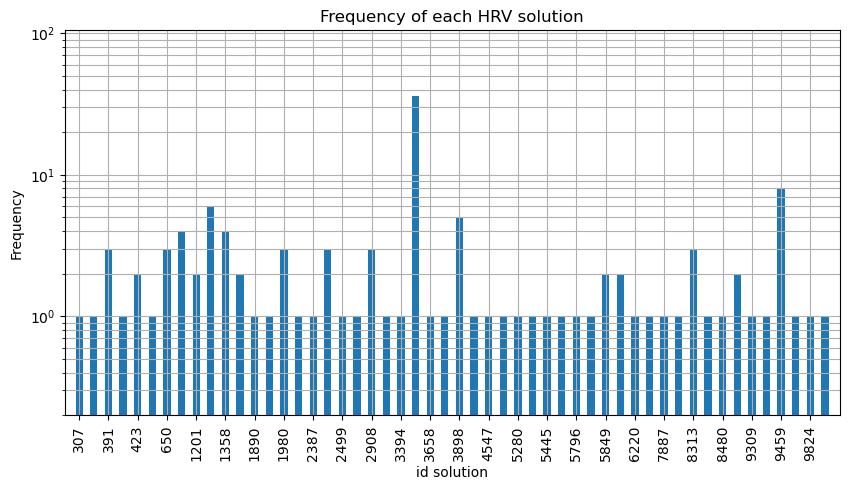

'A total of 52 solutions identified'

In [182]:
view_HRV_freq(best_sol_vhz,freq_sol_vhz,dx=2)

In [183]:
# most dominant solution and frequency
best_sol_vhz[23], freq_sol_vhz[23,:]

(np.int64(3480), array([ 0,  0,  1, 35]))

## 4. GAA problem multiple algorithms (10 Objectives)

### Now test with the GAA problem

In [184]:
# load the Excel file with the different solutions of Pareto front and Pareto set
filename = 'GAA/GAA_MOO.xls'

df_gaa = pd.read_excel(filename, sheet_name=0, header=0)

df_gaa['$RANGE [10^{3}nmi]$'] *= -1.0
df_gaa['$LDMAX [Ratio]$'] *= -1.0
df_gaa['$VCMAX [knots]$'] *= -1.0
df_gaa.head()

,ALGORITHM,$NOISE [dB]$,$WEMP [10^{3}lb]$,$DOC [USD/hr]$,$ROUGH [Ratio]$,$WFUEL [10^{2}lb]$,$PURCH [10^{3}USD]$,$RANGE [10^{3}nmi]$,$LDMAX [Ratio]$,$VCMAX [knots]$,...,TAPER4,CSPD6,AR6,SWEEP6,DPROP6,WINGLD6,AF6,SEATW6,ELODT6,TAPER6
0,2,73.849038,1.950129,59.781232,1.888365,4.262706,43.549604,2.029819,14.876334,196.393386,...,0.475269,0.240238,7.591070,5.611444,5.625784,23.626033,85.256005,18.459719,3.744443,0.481571
1,2,73.285267,1.953214,79.805768,1.930696,4.252236,43.290384,2.328814,15.302294,191.772425,...,0.498979,0.314680,7.079204,3.022159,5.500045,21.832243,87.637879,18.671505,3.661989,0.496724
2,2,73.634287,1.960262,62.401509,1.904507,4.194810,43.599497,2.124064,14.852269,193.481654,...,0.471815,0.244045,7.158738,4.410826,5.607004,22.643965,90.458060,18.980970,3.712806,0.481555
3,2,73.343767,1.972822,77.127543,1.962998,4.038559,43.714067,2.206617,15.604315,192.105663,...,0.485129,0.286624,7.678927,0.089579,5.513992,21.987356,86.437621,18.959736,3.746625,0.503160
4,2,73.332009,1.909893,62.622987,1.859312,4.486764,42.738621,2.107122,14.896494,197.746359,...,0.460694,0.240011,7.177425,5.913802,5.502678,24.088620,85.252496,17.263060,3.715281,0.475568


In [185]:
OFnames_gaa = ['NOISE \n [$dB$]', 'WEMP \n [$10^{3}lb$]', 'DOC \n [$USD/hr$]',
       'ROUGH \n [Ratio]', 'WFUEL \n [$10^{2}lb$]', 'PURCH \n [$10^{3}USD$]',
       'RANGE \n [$10^{3}nmi$]', 'LDMAX \n [Ratio]', 'VCMAX \n [knots]',
       'PFPF \n [Ratio]']

In [186]:
OF_gaa = df_gaa[['$NOISE [dB]$', '$WEMP [10^{3}lb]$', '$DOC [USD/hr]$',
       '$ROUGH [Ratio]$', '$WFUEL [10^{2}lb]$', '$PURCH [10^{3}USD]$',
       '$RANGE [10^{3}nmi]$', '$LDMAX [Ratio]$', '$VCMAX [knots]$',
       '$PFPF [Ratio]$']].to_numpy()
OF_gaa.shape

(12929, 10)

In [187]:
best_sol_gaa, freq_sol_gaa = HRV_method_2(OF_gaa, type="full", IDx=None)

HR_{[ 2  3  4  5  6  7  8  9 10]} vs HR_{[1]} : S_{6137}
HR_{[ 1  3  4  5  6  7  8  9 10]} vs HR_{[2]} : S_{12690}
HR_{[ 1  2  4  5  6  7  8  9 10]} vs HR_{[3]} : S_{4724}
HR_{[ 1  2  3  5  6  7  8  9 10]} vs HR_{[4]} : S_{5521}
HR_{[ 1  2  3  4  6  7  8  9 10]} vs HR_{[5]} : S_{11310}
HR_{[ 1  2  3  4  5  7  8  9 10]} vs HR_{[6]} : S_{7003}
HR_{[ 1  2  3  4  5  6  8  9 10]} vs HR_{[7]} : S_{11332}
HR_{[ 1  2  3  4  5  6  7  9 10]} vs HR_{[8]} : S_{5835}
HR_{[ 1  2  3  4  5  6  7  8 10]} vs HR_{[9]} : S_{5688}
HR_{[1 2 3 4 5 6 7 8 9]} vs HR_{[10]} : S_{6137}
HR_{[ 3  4  5  6  7  8  9 10]} vs HR_{[1 2]} : S_{12690}
HR_{[ 2  4  5  6  7  8  9 10]} vs HR_{[1 3]} : S_{6738}
HR_{[ 2  3  5  6  7  8  9 10]} vs HR_{[1 4]} : S_{5521}
HR_{[ 2  3  4  6  7  8  9 10]} vs HR_{[1 5]} : S_{11104}
HR_{[ 2  3  4  5  7  8  9 10]} vs HR_{[1 6]} : S_{12690}
HR_{[ 2  3  4  5  6  8  9 10]} vs HR_{[1 7]} : S_{11332}
HR_{[ 2  3  4  5  6  7  9 10]} vs HR_{[1 8]} : S_{5835}
HR_{[ 2  3  4  5  6  7  8 10]} vs HR_{[

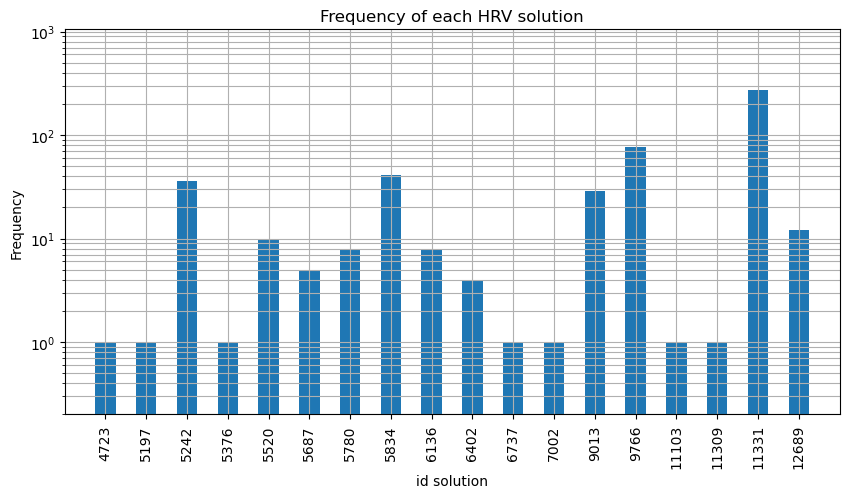

'A total of 18 solutions identified'

In [188]:
view_HRV_freq(best_sol_gaa,freq_sol_gaa,dx=1)

In [189]:
freq_sol_gaa.sum(axis=1)

array([  1,   1,  36,   1,  10,   5,   8,  41,   8,   4,   1,   1,  29,
        77,   1,   1, 274,  12])

In [190]:
best_sol_gaa

array([ 4723,  5197,  5242,  5376,  5520,  5687,  5780,  5834,  6136,
        6402,  6737,  7002,  9013,  9766, 11103, 11309, 11331, 12689])

In [191]:
freq_sol_gaa.sum(axis=0).sum()

np.int64(511)

In [197]:
df_gaa.iloc[11330][['$NOISE [dB]$', '$WEMP [10^{3}lb]$', '$DOC [USD/hr]$',
       '$ROUGH [Ratio]$', '$WFUEL [10^{2}lb]$', '$PURCH [10^{3}USD]$',
       '$RANGE [10^{3}nmi]$', '$LDMAX [Ratio]$', '$VCMAX [knots]$',
       '$PFPF [Ratio]$']]

$NOISE [dB]$            73.271609
$WEMP [10^{3}lb]$        1.962516
$DOC [USD/hr]$          63.331296
$ROUGH [Ratio]$          1.994735
$WFUEL [10^{2}lb]$       4.187665
$PURCH [10^{3}USD]$     43.687994
$RANGE [10^{3}nmi]$      2.101071
$LDMAX [Ratio]$         15.901014
$VCMAX [knots]$        195.516121
$PFPF [Ratio]$           0.086280
Name: 11330, dtype: float64